# GraphGenerator on ZINC

This notebook demonstrates the two-stage `GraphGenerator`: first generate a new interpretation graph, then instantiate base molecules conditionally from nearby ZINC examples.

In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from collections import Counter

import random
import networkx as nx
from nsppk import NSPPK
from sklearn.ensemble import RandomForestClassifier

from abstractgraph.display import display, display_decomposition_graph, display_mappings
from abstractgraph.graphs import graph_to_abstract_graph
from abstractgraph.operators import *
from abstractgraph_graphicalizer.chem import ZINCLoader, draw_molecules as display_graphs
from abstractgraph_ml.estimators import GraphEstimator
from abstractgraph_generative.conditional import ConditionalAutoregressiveGenerator
from abstractgraph_generative.edge_generator import EdgeGenerator
from abstractgraph_generative.graph_generator import GraphGenerator
from abstractgraph_ml.feasibility import FeasibilityEstimator, FeasibilityEstimatorFeatureCannotExist



In [3]:
def draw(graph, decomposition_function, *, nbits=11, label_mode="operator", size=(12, 6), n_elements_per_row=8):
    ag = graph_to_abstract_graph(
        graph,
        decomposition_function=decomposition_function,
        nbits=nbits,
        label_mode=label_mode,
    )
    display(ag, size=size)
    display_mappings(ag, n_elements_per_row=n_elements_per_row)
    return ag


def graph_at_level(levels, level_idx, instance_idx=0):
    if level_idx >= len(levels):
        return None

    level_entry = levels[level_idx]
    if isinstance(level_entry, (nx.Graph, nx.DiGraph)):
        return level_entry
    if not level_entry:
        return None
    if len(level_entry) == 1:
        return level_entry[0]
    if instance_idx < len(level_entry):
        return level_entry[instance_idx]
    return level_entry[-1]


def draw_decomposition_hierarchy(
    graph_or_levels,
    graph_generator,
    *,
    title=None,
    instance_idx=0,
    show_input=False,
    draw_kwargs=None,
):
    draw_kwargs = dict(draw_kwargs or {})
    levels = list(graph_or_levels) if isinstance(graph_or_levels, list) else [graph_or_levels]
    if title:
        print(title)

    if show_input:
        graph = graph_at_level(levels, 0, instance_idx=instance_idx)
        if graph is not None:
            print(f"level 0 | nodes={graph.number_of_nodes()}, edges={graph.number_of_edges()}")
            display_graphs([graph], n_graphs_per_line=1)

    for stage_idx in reversed(range(len(graph_generator.conditional_generators))):
        stage_generator = graph_generator.conditional_generators[stage_idx]
        lower_graph = graph_at_level(levels, stage_idx, instance_idx=instance_idx)
        if lower_graph is None:
            print(f"stage {stage_idx}: level {stage_idx} -> level {stage_idx + 1} | missing")
            break

        print("-" * 80)
        print(
            f"stage {stage_idx}: level {stage_idx} -> level {stage_idx + 1} | "
            f"input nodes={lower_graph.number_of_nodes()}, input edges={lower_graph.number_of_edges()}"
        )
        ag = draw(
            lower_graph,
            decomposition_function=stage_generator.decomposition_function,
            nbits=stage_generator.nbits,
            label_mode=stage_generator.label_mode,
            **draw_kwargs,
        )
        next_graph = ag.interpretation_graph.copy()
        if len(levels) <= stage_idx + 1:
            levels.append(next_graph)
        print(
            f"level {stage_idx + 1} | nodes={next_graph.number_of_nodes()}, "
            f"edges={next_graph.number_of_edges()}"
        )
    return levels


def preview_random_decomposition(graphs, graph_generator, *, random_state=0, draw_kwargs=None):
    preview_rng = random.Random(random_state)
    preview_idx = preview_rng.randrange(len(graphs))
    preview_graph = graphs[preview_idx].copy()
    return draw_decomposition_hierarchy(
        preview_graph,
        graph_generator,
        title=f"preview input graph index: {preview_idx}",
        show_input=True,
        draw_kwargs=draw_kwargs,
    )


def summarize_generation(graph_generator, generated_graphs):
    generated_interpretation_graphs = [
        levels[-1][0]
        for levels in graph_generator.last_level_generated_graphs_history_
        if levels and levels[-1]
    ]
    print(f"generated molecules: {len(generated_graphs)}")
    print("attempted seed indices:", graph_generator.last_sampled_indices_)
    print("successful seed indices:", graph_generator.last_successful_sampled_indices_)
    print("successful interpretation targets:", len(generated_interpretation_graphs))
    if not generated_graphs:
        print("No molecules generated; inspect warnings and try a larger neighborhood or dataset slice.")
    return generated_interpretation_graphs


def display_generated_hierarchies(
    graph_generator,
    generated_graphs,
    *,
    draw_kwargs=None,
    molecule_draw_kwargs=None,
):
    if not generated_graphs:
        print("No generated molecules to display.")
        return

    molecule_draw_kwargs = dict(molecule_draw_kwargs or {})
    molecule_draw_kwargs.setdefault("n_graphs_per_line", 1)

    histories = list(zip(
        graph_generator.last_successful_sampled_indices_,
        graph_generator.last_level_seed_graphs_history_,
        graph_generator.last_level_generated_graphs_history_,
    ))
    if not histories:
        print(
            "No generated hierarchy history is available on this generator. "
            "Rerun generator.sample(...) after the current generator is created "
            "to display decomposition hierarchies."
        )
        print(f"generated molecules: {len(generated_graphs)}")
        display_graphs(generated_graphs, **molecule_draw_kwargs)
        return

    for sample_idx, (seed_idx, seed_levels, generated_levels) in enumerate(histories):
        generated_instances = generated_levels[0]
        print("=" * 120)
        print(f"sample {sample_idx} | seed index {seed_idx}")
        seed_graph = graph_at_level(seed_levels, 0)
        if seed_graph is not None:
            print("seed molecule")
            display_graphs([seed_graph], **molecule_draw_kwargs)
        draw_decomposition_hierarchy(
            seed_levels,
            graph_generator,
            title="seed graph hierarchy",
            draw_kwargs=draw_kwargs,
        )
        for instance_idx, generated_instance in enumerate(generated_instances):
            print("-" * 80)
            print(f"generated molecule | instance {instance_idx}")
            display_graphs([generated_instance], **molecule_draw_kwargs)
            draw_decomposition_hierarchy(
                generated_levels,
                graph_generator,
                title=f"generated graph hierarchy | instance {instance_idx}",
                instance_idx=instance_idx,
                draw_kwargs=draw_kwargs,
            )


---

In [4]:
loader = ZINCLoader(on_error="skip")

dataset_name = "zinc_250k"
size = 300
min_num_nodes = 30
max_num_nodes = 50

graphs, metadata = loader.load(
    dataset_name,
    limit=size,
    min_node_count=min_num_nodes,
    max_node_count=max_num_nodes,
)

print(f"dataset: {dataset_name}")
print(f"n_graphs: {len(graphs)}")
print(f"node_range: [{min_num_nodes}, {max_num_nodes}]")


dataset: zinc_250k
n_graphs: 300
node_range: [30, 50]


In [5]:
label_mode = "operator" #label_mode: str = "operator" (default) or "histogram" or "histogram_values" for AbstractGraph node labeling.
nbits = 14
#------------------------------------------------------------------------------------------------------------------------------------------------------------------------
feasibility_kwargs = dict(
    nbits=19,
    parallel=True,
    backend="loky",
    n_jobs=-1,
)
partial_feasibility_estimators = [
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(neighborhood(radius=2), unlabel()),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=neighborhood(radius=1),
        **feasibility_kwargs,
    ),
]
partial_feasibility_estimator = FeasibilityEstimator(partial_feasibility_estimators)

final_feasibility_estimators = [
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(neighborhood(radius=2), unlabel()),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=neighborhood(radius=1),
        **feasibility_kwargs,
    ),
]
final_feasibility_estimator = FeasibilityEstimator(final_feasibility_estimators)
#------------------------------------------------------------------------------------------------------------------------------------------------------------------------
edge_estimator_vectorizer = NSPPK(radius=1, distance=4, connector=0, nbits=14, dense=True, parallel=True)
edge_graph_estimator = GraphEstimator(
    transformer=edge_estimator_vectorizer,
    estimator=RandomForestClassifier(
        n_estimators=80,
        random_state=0,
        n_jobs=-1,
        class_weight="balanced_subsample",
    ),
)
edge_generator = EdgeGenerator(
    partial_feasibility_estimator=partial_feasibility_estimator,
    final_feasibility_estimator=final_feasibility_estimator,
    graph_estimator=edge_graph_estimator,
    n_negative_per_positive=3,
    n_replicates=2,
    beam_size=3,
    max_restarts=2,
    fit_n_jobs=-1,
    fit_backend="loky",
    seed=0,
)

#------------------------------------------------------------------------------------------------------------------------------------------------------------------------
level0_decomposition_function = compose(
    intersection_edges(),
    add(compose(name('c'), cycle()), compose(name('t'), tree()))
)
level1_decomposition_function = compose(
    intersection_edges(),
    compose(
        name('cut'),
            low_cut_partition(
                max_part_size=4,
                min_part_size=3,
                target_max_boundary_nodes=2,
                target_max_cut_edges=3,
                min_overlap_nodes=1,
                seed=7,
            )
    )
)
context_vectorizer = NSPPK(radius=1, distance=4, connector=0, nbits=14, dense=True, parallel=True)

conditional_generator0 = ConditionalAutoregressiveGenerator(
    decomposition_function=level0_decomposition_function,
    nbits=nbits,
    label_mode=label_mode,
    base_cut_radius=0,
    interpretation_cut_radius=1,
    context_vectorizer=context_vectorizer,
    n_jobs=1,
)

conditional_generator1 = ConditionalAutoregressiveGenerator(
    decomposition_function=level1_decomposition_function,
    nbits=nbits,
    label_mode=label_mode,
    base_cut_radius=0,
    interpretation_cut_radius=1,
    context_vectorizer=context_vectorizer,
    n_jobs=1,
)

#------------------------------------------------------------------------------------------------------------------------------------------------------------------------
generator = GraphGenerator(
    conditional_generators=[conditional_generator0, conditional_generator1],
    edge_generator=edge_generator,
    seed=None,
    debug=True,
    require_new_interpretation_graph=True,
    max_same_interpretation_retries=3,
)

preview input graph index: 191
level 0 | nodes=30, edges=32


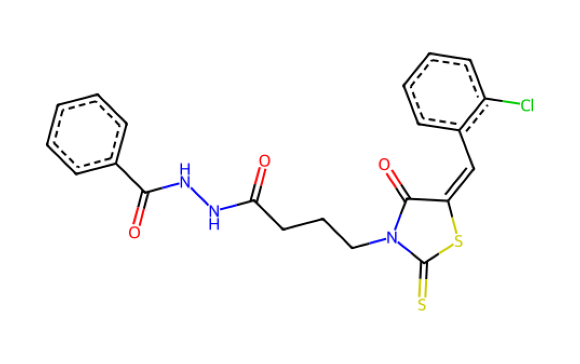

stage 1: level 1 -> level 2 | missing


In [6]:
preview_levels = preview_random_decomposition(
    graphs,
    generator,
    random_state=None,
    draw_kwargs=dict(size=(7, 4), n_elements_per_row=6),
)


In [7]:
%%time
generator.store(graphs)

CPU times: user 14.9 s, sys: 4.81 s, total: 19.8 s
Wall time: 13.5 s


In [8]:
%%time
n_samples = 1
n_instances_per_sample = 3
generated_graphs = generator.sample(
    n_samples=n_samples,
    n_interpretation_neighbors=20,
    n_conditional_neighbors=50,
    n_instances_per_sample=n_instances_per_sample,
    interpretation_edge_removal_size=.5,  # 0 bypasses edge generation; 1 removes all interpretation edges before regrowth.
    random_state=None,
    conditional_generate_kwargs=dict(
        random_state=None,
        max_backtracks=2000,
        max_attempts_per_sample=2,
        require_signature_coverage=True,
    ),
)

generated_interpretation_graphs = summarize_generation(generator, generated_graphs)


[graph-generator sample] event=seed_start currently_generated=0/1 attempted_seeds=1/10 generated_graphs=0 seed_idx=187
[graph-generator edge] seed_idx=187 n_neighbors=19 neighbor_indices=[169, 57, 257, 260, 3, 2, 6, 119, 118, 50, 62, 0, 185, 8, 69, 1, 81, 96, 125] neighbor_distances=[0.0, 16.1555, 16.1555, 17.1464, 17.3494, 18.1659, 18.3576, 18.6815, 20.9045, 21.2132, 22.4277, 22.4944, 23.7065, 23.8747, 26.2488, 27.2947, 29.6985, 44.6878, 48.3011]
[fit] partial_feasibility_graphs=121 positives=144 negatives=324 dataset=468 partial_time=0m 0.4s
[fit] final_feasibility_graphs=19 final_time=0m 0.1s
[fit] lookahead_envelope_stages=8 lookahead_examples=144 lookahead_rejection_model=lognormal_tail
[fit] graph_estimator_graphs=432 positive_labels=108 negative_labels=324 time=0m 2.7s
[graph 0] start start_edges=2 target_edges=4 remaining_edges=2
[graph 0] search_phase=1/3 beam_limit=3
[graph 0] remaining_edges=1
search_phase=1/3 depth=1 step_time=0m 0.7s eta=0m 0.7s
tried=8 generated=8 partial

/Users/f.costa/Code/abstractgraph-ecosystem/repos/abstractgraph-generative/src/abstractgraph_generative/graph_generator.py:537: RuntimeWarning: Edge stage generated the same interpretation graph as the sampled seed after 3 retries; skipping seed.
  generated_top_graph = self._generate_interpretation_graph_with_retries(


[fit] partial_feasibility_graphs=115 positives=144 negatives=324 dataset=468 partial_time=0m 0.5s
[fit] final_feasibility_graphs=19 final_time=0m 0.1s
[fit] lookahead_envelope_stages=8 lookahead_examples=144 lookahead_rejection_model=lognormal_tail
[fit] graph_estimator_graphs=432 positive_labels=108 negative_labels=324 time=0m 2.2s
[graph 0] start start_edges=1 target_edges=2 remaining_edges=1
[graph 0] search_phase=1/3 beam_limit=3
[graph 0] remaining_edges=0
search_phase=1/3 depth=1 step_time=0m 0.1s eta=0m 0.0s
tried=2 generated=2 partial_feasible=2 viable=2 retained=1
best_score=0.437 best_selection_score=0.237 best_repulsion=1.000
repulsion_lambda=0.200 beam_limit=3
[graph 0] solved search_phase=1/3 depth=1 max_depth=1 edges=2 edge_shortfall=0 remaining_edges=0 tried=2 elapsed=0m 0.1s eta=0m 0.0s
[graph-generator edge] generated same interpretation graph as seed; retry=1/3
[graph 0] start start_edges=1 target_edges=2 remaining_edges=1
[graph 0] search_phase=1/3 beam_limit=3
[grap

/Users/f.costa/Code/abstractgraph-ecosystem/repos/abstractgraph-generative/src/abstractgraph_generative/graph_generator.py:537: RuntimeWarning: Edge stage generated the same interpretation graph as the sampled seed after 3 retries; skipping seed.
  generated_top_graph = self._generate_interpretation_graph_with_retries(


[fit] partial_feasibility_graphs=117 positives=144 negatives=324 dataset=468 partial_time=0m 0.3s
[fit] final_feasibility_graphs=19 final_time=0m 0.1s
[fit] lookahead_envelope_stages=8 lookahead_examples=144 lookahead_rejection_model=lognormal_tail
[fit] graph_estimator_graphs=432 positive_labels=108 negative_labels=324 time=0m 1.8s
[graph 0] start start_edges=1 target_edges=1 remaining_edges=0
[graph 0] solved depth=0 max_depth=0 edges=1 remaining_edges=0 tried=0 elapsed=0m 0.0s eta=0m 0.0s
[graph-generator edge] generated same interpretation graph as seed; retry=1/3
[graph 0] start start_edges=1 target_edges=1 remaining_edges=0
[graph 0] solved depth=0 max_depth=0 edges=1 remaining_edges=0 tried=0 elapsed=0m 0.0s eta=0m 0.0s
[graph-generator edge] generated same interpretation graph as seed; retry=2/3
[graph 0] start start_edges=1 target_edges=1 remaining_edges=0
[graph 0] solved depth=0 max_depth=0 edges=1 remaining_edges=0 tried=0 elapsed=0m 0.0s eta=0m 0.0s
[graph-generator edge] 

...

/Users/f.costa/Code/abstractgraph-ecosystem/repos/abstractgraph-generative/src/abstractgraph_generative/graph_generator.py:537: RuntimeWarning: Edge stage generated the same interpretation graph as the sampled seed after 3 retries; skipping seed.
  generated_top_graph = self._generate_interpretation_graph_with_retries(


[fit] partial_feasibility_graphs=115 positives=144 negatives=324 dataset=468 partial_time=0m 0.3s
[fit] final_feasibility_graphs=19 final_time=0m 0.1s
[fit] lookahead_envelope_stages=8 lookahead_examples=144 lookahead_rejection_model=lognormal_tail
[fit] graph_estimator_graphs=432 positive_labels=108 negative_labels=324 time=0m 1.7s
[graph 0] start start_edges=1 target_edges=1 remaining_edges=0
[graph 0] solved depth=0 max_depth=0 edges=1 remaining_edges=0 tried=0 elapsed=0m 0.0s eta=0m 0.0s
[graph-generator edge] generated same interpretation graph as seed; retry=1/3
[graph 0] start start_edges=1 target_edges=1 remaining_edges=0
[graph 0] solved depth=0 max_depth=0 edges=1 remaining_edges=0 tried=0 elapsed=0m 0.0s eta=0m 0.0s
[graph-generator edge] generated same interpretation graph as seed; retry=2/3
[graph 0] start start_edges=1 target_edges=1 remaining_edges=0
[graph 0] solved depth=0 max_depth=0 edges=1 remaining_edges=0 tried=0 elapsed=0m 0.0s eta=0m 0.0s
[graph-generator edge] 

/Users/f.costa/Code/abstractgraph-ecosystem/repos/abstractgraph-generative/src/abstractgraph_generative/graph_generator.py:537: RuntimeWarning: Edge stage generated the same interpretation graph as the sampled seed after 3 retries; skipping seed.
  generated_top_graph = self._generate_interpretation_graph_with_retries(


[fit] partial_feasibility_graphs=119 positives=144 negatives=324 dataset=468 partial_time=0m 0.2s
[fit] final_feasibility_graphs=19 final_time=0m 0.1s
[fit] lookahead_envelope_stages=8 lookahead_examples=144 lookahead_rejection_model=lognormal_tail
[fit] graph_estimator_graphs=432 positive_labels=108 negative_labels=324 time=0m 1.6s
[graph 0] start start_edges=1 target_edges=2 remaining_edges=1
[graph 0] search_phase=1/3 beam_limit=3
[graph 0] remaining_edges=0
search_phase=1/3 depth=1 step_time=0m 0.1s eta=0m 0.0s
tried=2 generated=2 partial_feasible=2 viable=2 retained=1
best_score=0.444 best_selection_score=0.244 best_repulsion=1.000
repulsion_lambda=0.200 beam_limit=3
[graph 0] solved search_phase=1/3 depth=1 max_depth=1 edges=2 edge_shortfall=0 remaining_edges=0 tried=2 elapsed=0m 0.1s eta=0m 0.0s
[graph-generator edge] generated same interpretation graph as seed; retry=1/3
[graph 0] start start_edges=1 target_edges=2 remaining_edges=1
[graph 0] search_phase=1/3 beam_limit=3
[grap

/Users/f.costa/Code/abstractgraph-ecosystem/repos/abstractgraph-generative/src/abstractgraph_generative/graph_generator.py:537: RuntimeWarning: Edge stage generated the same interpretation graph as the sampled seed after 3 retries; skipping seed.
  generated_top_graph = self._generate_interpretation_graph_with_retries(


In [9]:
display_generated_hierarchies(
    generator,
    generated_graphs,
    draw_kwargs=dict(size=(7, 4), n_elements_per_row=6),
)

No generated molecules to display.
